In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import sys

from taurex.log import disableLogging

import taurex
taurex.log.disableLogging()

from taurex.cache import OpacityCache,CIACache
OpacityCache().clear_cache()
OpacityCache().set_opacity_path("./xsec")
CIACache().set_cia_path("./cia")

from taurex.mixin import enhance_class
from taurex.planet import Planet
from taurex.stellar import PhoenixStar, BlackbodyStar

from taurex.data.profiles.pressure import SimplePressureProfile
from taurex.temperature import Guillot2010, NPoint, Isothermal
from taurex.constants import AU, RJUP

from taurex.temperature import TemperatureFile
from taurex.data.profiles.chemistry import TaurexChemistry
from taurex.chemistry import ConstantGas

from taurex.contributions import AbsorptionContribution
from taurex.contributions import CIAContribution
from taurex.contributions import RayleighContribution

from explor.model import HotSpotPhaseCurveModel
import astropy

import pandas as pd
import numpy as np
import os
import xarray as xr
from taurex.binning import FluxBinner
from taurex.util.util import create_grid_res
from matplotlib.pyplot import cm

Numba not installed, using numpy instead


In [44]:
planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
planet_masses = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44] #Earth masses
planet_distances = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012] #AU
planet_period = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55] #days
planet_radius = [1.627, 1.510, 1.242, 1.277, 1.166, 1.397, 1.620, 1.496] #Earth radii
planet_transit = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98]*3600 #hours to seconds
planet_impact = [0.181, -0.01, 0.717, 0.34, 0.53, 0.14, 0.39, 0.489] #to be fixed according to archive data
planet_eccentricity = [0.05, 0.0, 0.0, 0.0, 0.06, 0.0, 0.0, 0.0] #to be fixed according to archive data
planet_pericentre_long = [0.0, 90.0, 0.0, 0.0, 228.5, 0.0, 0.0, 90.0] #w, to be fixed according to archive data


star_temperature = [5261.0,4570.0,3381.0,4850.0,4440.0,5342.0,4884.0,4914.0] #Kelvin
star_radius = [0.872,0.681,0.246,0.731,0.678,0.856,0.793,0.746] #Solar radii
star_metallicity = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04] #[Fe/H]
star_logg = [4.5, 4.6, 4.9, 4.6, 4.6, 4.5, 4.5, 4.6]
star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3] #Gyr
star_distance = [47.28, 61.87, 18.22, 32.6, 47.39, 85.8, 55.01, 42.58] #pc, to be fixed

name = planet_names[1]
H = '10'
iw = '4'
eff = '00001'
#optional
S = '10'

mass = planet_masses[planet_names.index(name)] #Earth masses
#convert to jupiter masses
mass_jup = mass / 317.8
#semi-major axis
a = planet_distances[planet_names.index(name)] #AU

radius = planet_radius[planet_names.index(name)] #planet radius in m

#convert to Jupiter radii
radius_jup = radius * (astropy.constants.R_earth.value / astropy.constants.R_jup.value)


#set-up planet in Jupiter masses and radii
pl = Planet(planet_mass=mass_jup, planet_radius= radius_jup, planet_sma=a, planet_distance=star_distance[planet_names.index(name)], 
            impact_param=planet_impact[planet_names.index(name)], orbital_period=planet_period[planet_names.index(name)], 
            transit_time=planet_transit[planet_names.index(name)])

st = PhoenixStar(temperature=star_temperature[planet_names.index(name)], radius=star_radius[planet_names.index(name)], metallicity=star_metallicity[planet_names.index(name)],distance=star_distance[planet_names.index(name)], phoenix_path='Phoenix/')

In [ ]:
pl._mid_time = 0 #T_c, leave at 0
pl.pericentre_time = 0.0 # leave to 0
pl.ascending_node_long = 0.0 # leave to 0

pl._eccentricity = planet_eccentricity[planet_names.index(name)] # eccentricity
pl._pericentre_long = planet_pericentre_long[planet_names.index(name)] #w

#convert from seconds to days
transittime = pl.transitTime*1.15741e-5
begin = pl._mid_time-planet_period[planet_names.index(name)]/2-2*transittime
end = pl._mid_time+planet_period[planet_names.index(name)]/2+2*transittime

phases = np.linspace(begin, end, 200)

In [30]:
#PRESSURE PROFILE
# pressure profile from  planet specific csv file
path_to_csv = f'./PLANETS/{name}/H{H}_IW{iw}_{eff}_S{S}_TP.csv'

#open the csv file and extract pressure and temperature
data = pd.read_csv(path_to_csv)
pressure = data['Pressure (Pa)'].values

p1 = SimplePressureProfile(nlayers=100, atm_min_pressure=np.min(pressure), atm_max_pressure=np.max(pressure))
p1.compute_pressure_profile()

ps = [p1,p1,p1]

In [31]:
#TEMPREATURE PROFILE
#temperature profile from  planet specific csv file

planetdir = f'./PLANETS/{name}/H{H}_IW{iw}_{eff}_S{S}_TP.csv'

tp1 = TemperatureFile(planetdir, skiprows=1,
                               temp_col=1, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')

tp2 = TemperatureFile(planetdir, skiprows=1,
                               temp_col=2, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')


temperatures = [tp2, tp2, tp1]

In [32]:
for folder in os.listdir(f"./PLANETS/{name}/"):
    simulation_folder = os.path.join(f"PLANETS/{name}/", folder)
    #check if it is a directory
    if not os.path.isdir(simulation_folder):
        continue
    for file in os.listdir(f"./{simulation_folder}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"./{simulation_folder}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break

    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    # check that the sum of all vmr is less or equal to 1
    total_vmr = H2O_x + CO2_x + CH4_x + CO_x + NH3_x + N2_x + SO2_x + S2_x + O2_x + H2_x + H2S_x
    if total_vmr > 1:
        #renormalize the vmr values
        H2O_x = H2O_x / total_vmr
        CO2_x = CO2_x / total_vmr
        CH4_x = CH4_x / total_vmr
        CO_x = CO_x / total_vmr
        NH3_x = NH3_x / total_vmr
        N2_x = N2_x / total_vmr
        SO2_x = SO2_x / total_vmr
        S2_x = S2_x / total_vmr
        O2_x = O2_x / total_vmr
        H2_x = H2_x / total_vmr
        H2S_x = H2S_x / total_vmr

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))


chemistries = [chemistry, chemistry, chemistry]

In [33]:
ctribs = [[AbsorptionContribution(), RayleighContribution(), CIAContribution(cia_pairs=['CO2-CO2','CO2-H2','CO2-H2O','H2-H2','O2-CO2'])],
                                [AbsorptionContribution(),RayleighContribution(), CIAContribution(cia_pairs=['CO2-CO2','CO2-H2','CO2-H2O','H2-H2','O2-CO2'])],
                                [AbsorptionContribution(),RayleighContribution(), CIAContribution(cia_pairs=['CO2-CO2','CO2-H2','CO2-H2O','H2-H2','O2-CO2'])]]

In [34]:
hs = HotSpotPhaseCurveModel(phases=phases,
                 temperature_profiles=temperatures,
                 chemistry=chemistries,
                 nlayers=[70]*3,
                 pressure_profile=ps,
                 planet=pl,
                 star=st,
                 observation=None,
                 contributions=ctribs,
                 alpha_hs=45.0,
                 delta_hs = -40.0,
                 ngauss=40,
                 use_directimage=False,
                 use_cuda=False,
                 use_orbitals = True,
                 temperature_constraints = 10, res_grid=[400, 0.2, 18.5])

None
File already here...  teff04500_logg4.5_MH0.0.pickle
File already here...  teff04500_logg5.0_MH0.0.pickle
File already here...  teff04750_logg4.5_MH0.0.pickle
File already here...  teff04750_logg5.0_MH0.0.pickle


In [35]:
hs.build()

In [36]:
o = hs.model()

/Users/lorenzo/anaconda3/envs/python312_env/lib/python3.12/site-packages/explor/util/pylightcurve.py:84: RuntimeWarning: divide by zero encountered in scalar divide
  position_vector = planet_orbit(period, sma_over_rs / rp_over_rs, eccentricity, inclination, periastron + 180,
/Users/lorenzo/anaconda3/envs/python312_env/lib/python3.12/site-packages/explor/util/pylightcurve.py:88: RuntimeWarning: divide by zero encountered in scalar divide
  position_vector[0] < 0, 1.0 + 5.0 / rp_over_rs,
/Users/lorenzo/anaconda3/envs/python312_env/lib/python3.12/site-packages/explor/util/pylightcurve.py:91: RuntimeWarning: divide by zero encountered in scalar divide
  return (1.0 + fp_over_fs * transit_flux_drop([0, 0, 0, 0], 1 / rp_over_rs, projected_distance,
/Users/lorenzo/anaconda3/envs/python312_env/lib/python3.12/site-packages/explor/util/pylightcurve.py:115: RuntimeWarning: invalid value encountered in subtract
  dif_z_rprs = rp_over_rs - z_over_rs
/Users/lorenzo/anaconda3/envs/python312_env/lib/

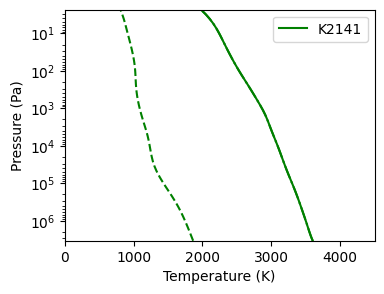

In [37]:
#sanity check of temperature profile

plt.figure(figsize=(4, 3))

plt.plot(hs.temperatureProfile[0,:], hs.pressureProfile[0,:], color='green', label=f'{name}')
plt.plot(hs.temperatureProfile[1,:], hs.pressureProfile[0,:],'-.', color='green')
plt.plot(hs.temperatureProfile[2,:], hs.pressureProfile[0,:],'--', color='green')

plt.legend()
plt.yscale('log')
plt.gca().invert_yaxis()
plt.xlim(000, 4500)
plt.ylim(np.max(hs.pressureProfile), np.min(hs.pressureProfile))
plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (Pa)')
#plt.savefig('all_tp.png',bbox_inches='tight', dpi=180)
plt.show()

In [38]:
ariel = pd.read_csv(f'./ARIEL/arielrad_{name}/tier2.csv', skiprows=6)
fb_ariel = FluxBinner(ariel['Wavelength [um]'], ariel['Bandwidth [um]'])
wave = ariel['Wavelength [um]'].values
band = ariel['Bandwidth [um]'].values
error_w_floor = ariel['Noise on Transit Floor [ppm]'].values*1e-6
error_w_hour = ariel['Total Noise [ppm]'].values*1e-6/np.sqrt(1)

flux = np.zeros((len(hs._orbitals), len(wave)))
fb2 = FluxBinner(wave)
for i, orb in enumerate(hs._orbitals):
    _, flux[i, :], _, _ = fb2.bindown(10000/hs.wls[0][::-1],np.array(o[1])[::-1,i])

In [39]:
dtsampled = np.mean(hs._orbitals[1:] - hs._orbitals[:-1])*24
dh = error_w_hour / np.sqrt(dtsampled)

4


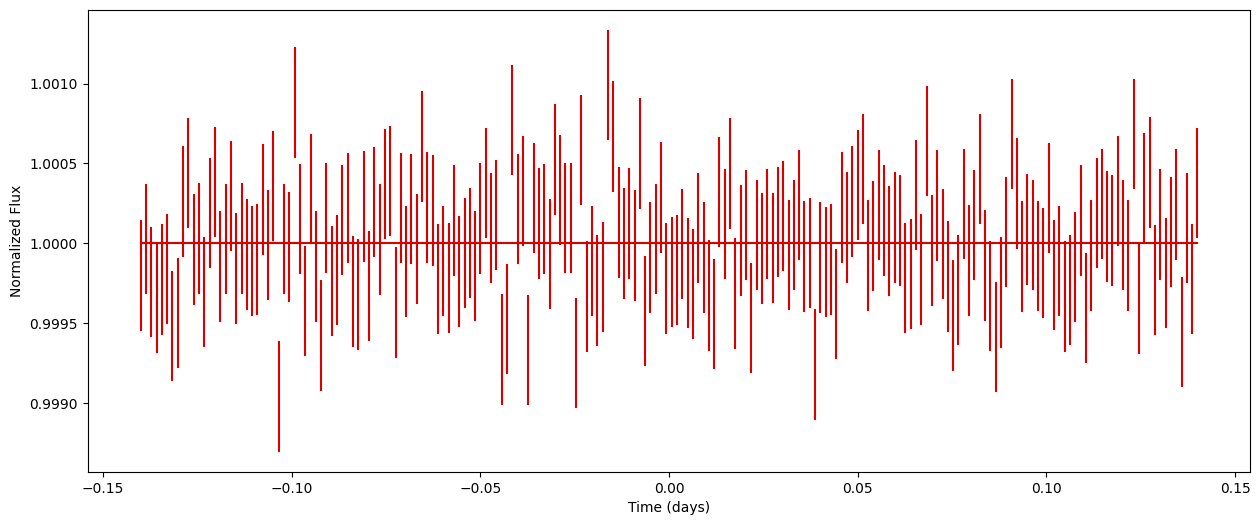

In [43]:
plt.figure(figsize=(15,6))
Nphases = int(len(np.array(o[1])[:,0])/2)
from matplotlib.pyplot import cm
c = cm.jet(np.linspace(1, 0, len(wave)))

wl = [wave[4]]
for i, w in enumerate(wl):
    idx = (np.abs(wave - w)).argmin()
    print(idx)
    plt.plot(hs._orbitals, flux[:, idx], color=c[idx])
    rand = np.random.normal(flux[:, idx], dh[idx])
    plt.plot((hs._orbitals,hs._orbitals), (rand-dh[idx],rand+dh[idx]),'-', color=c[idx])

plt.xlabel('Time (days)')
plt.ylabel('Normalized Flux')

plt.show()